# Build and Inspect SFC Fields

`SFCProjection` maps a particle catalogue onto scaling-function coefficients (SFCs). The resulting `SFCField` is the reusable field object consumed by PyHermes windows and correlation tasks.

This notebook starts from the same public Quijote halo catalogue and YAML as `quick_start.ipynb`, then focuses on the field language itself: catalogue and physical weights, resolution, redshift-space coordinates, and the companion particle dataset. For catalogue formats and conversion, see `particle_io.ipynb`.


In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np

from pyhermes.base import SFCProjection
from pyhermes.io import read_particle_data
from pyhermes.param.parambase import read_param
from pyhermes.utils.redshift_space import hubble_at_redshift, redshift_space_positions

cwd = Path.cwd().resolve()
if cwd.name == "notebooks" and cwd.parent.name == "examples":
    examples_dir = cwd.parent
elif cwd.name == "examples":
    examples_dir = cwd
elif (cwd / "examples").is_dir():
    examples_dir = cwd / "examples"
else:
    raise RuntimeError("Run this notebook from the project root, examples/, or examples/notebooks/.")

os.chdir(examples_dir)
Path("./output").mkdir(exist_ok=True)
Path("./figs").mkdir(exist_ok=True)
print(f"Working directory: {Path.cwd()}")


Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


## 1. Project the configuration-defined catalogue

The YAML is the source of truth for the URL, cache, box, MRA basis, normalization, and output paths. The equivalent command-line run is:

```bash
python scripts/run_sfc_projection.py configs/param_sfc_projection.yaml
```


In [3]:
projection_params = read_param("./configs/param_sfc_projection.yaml")
projection_config = projection_params["SFCProjection"]

projection_task = SFCProjection(projection_params)
field_j8 = projection_task.run(overwrite=True)


23:37:57 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_sfc_projection.yaml'
23:37:57 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
23:37:57 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
23:37:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.path' from 'empty' to 'https://pyhermes.astroslacker.com/downloads/quijote_halos_8000_snap004.npz'
23:37:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.format' from 'bin' to 'npz'
23:37:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.download.cache_path' from 'empty' to './data/quijote_halos_8000_snap004.npz'
23:37:57 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.fin.download.sha256' from 'empty' to 'b2b4b8c2fb91fa857e21b43d943cc32a2c423ee7cf5d7f13dede608264b08ef6'
23:37:57 - INFO - pyhermes.param.parambase:ParamBase - Defaul

In [4]:
print(f"epsilon shape: {field_j8.epsilon.shape}")
print(f"J={field_j8.J}, cells per axis={field_j8.L}, cell spacing={field_j8.box_size / field_j8.L:.3f} Mpc/h")
print(f"field integral: {field_j8.field_integral:.6g}")
print(f"normalization: {field_j8.weight_normalization}")


epsilon shape: (256, 256, 256)
J=8, cells per axis=256, cell spacing=3.906 Mpc/h
field integral: 1
normalization: catalog


## 2. Project arrays and physical field values

`catalog_weight` changes how objects contribute statistically; `field_value` is the scalar carried by each object. Here unit catalogue weights produce a number field, while halo mass as `field_value` produces a mass field. With `weight_normalization='catalog'`, their integrals are 1 and the mean halo mass, respectively.


In [5]:
fin = projection_config["fin"]
halo_data = read_particle_data(
    fin["path"],
    data_format=fin["format"],
    download=fin["download"],
    fields={
        "vel_x": "vel_x",
        "vel_y": "vel_y",
        "vel_z": "vel_z",
        "mass": "mass",
    },
)
pos = halo_data["pos"]
mass = halo_data["mass"]
print(f"Loaded {halo_data['size']:,} haloes")


23:38:15 - INFO - pyhermes.io.resources:resolve_data_path - Using cached particle data: data/quijote_halos_8000_snap004.npz
23:38:15 - INFO - pyhermes.io.readers:read_particle_data - Selected input particle format: npz
23:38:15 - INFO - pyhermes.io.readers:read_npz - Reading particle data from ---> data/quijote_halos_8000_snap004.npz <---
Loaded 406,728 haloes


In [6]:
def project_arrays(particle_pos, field_value=None, J=None):
    task_params = {
        "SFCProjection": {
            "particle_pos": particle_pos,
            "catalog_weight": None,
            "field_value": field_value,
            "box_size": projection_config["box_size"],
            "J": projection_config["J"] if J is None else J,
            "wavelet_mode": projection_config["wavelet_mode"],
            "wavelet_level": projection_config["wavelet_level"],
            "phi_resolution": projection_config["phi_resolution"],
            "weight_normalization": projection_config["weight_normalization"],
            "threads": projection_config["threads"],
            "save_particle_data": False,
            "fout_path": "",
        }
    }
    return SFCProjection(task_params).run(save_result=False)

mass_field = project_arrays(pos, field_value=mass)
print(f"number-field integral: {field_j8.field_integral:.6g}")
print(f"mass-field integral: {mass_field.field_integral:.6e}")
print(f"mean input halo mass: {mass.mean():.6e}")


23:38:33 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
23:38:33 - WARNING - pyhermes.param.parambase:ParamBase - Type mismatch for key: 'SFCProjection.particle_pos' !!!
23:38:33 - WARNING - pyhermes.param.parambase:ParamBase - Type mismatch for key: 'SFCProjection.field_value' !!!
23:38:33 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.threads' from '1' to '2'
23:38:33 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 2 threads per rank
23:38:33 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
23:38:33 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=8, L=256, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
23:38:33 - INFO - pyhermes.pipeline.pipeline:SFCProjection - No catalog_weight provided; using unit catalogue weights for 406728 particles.
23:38:33 - INFO - pyhermes.pipeline.pi

## 3. Resolution is an explicit modelling choice

Increasing `J` doubles the number of scaling cells along each axis. The comparison below evaluates both fields on the same physical plane, so only the represented field resolution changes.


In [7]:
field_j7 = project_arrays(pos, J=7)

box_size = projection_config["box_size"]
slice_resolution = 160
z_slice = 0.5 * box_size
axis = (np.arange(slice_resolution) + 0.5) * box_size / slice_resolution
xx, yy = np.meshgrid(axis, axis, indexing="xy")
slice_pos = np.column_stack([xx.ravel(), yy.ravel(), np.full(xx.size, z_slice)])

def density_contrast(field, sample_pos=slice_pos):
    density = field.field_density_at_pos(sample_pos, value_unit="physical")
    return (density / field.field_mean_density(value_unit="physical") - 1.0).reshape(xx.shape)

delta_j7 = density_contrast(field_j7)
delta_j8 = density_contrast(field_j8)


23:38:48 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
23:38:48 - WARNING - pyhermes.param.parambase:ParamBase - Type mismatch for key: 'SFCProjection.particle_pos' !!!
23:38:48 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.J' from '8' to '7'
23:38:48 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.threads' from '1' to '2'
23:38:48 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 2 threads per rank
23:38:48 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
23:38:48 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=7, L=128, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
23:38:48 - INFO - pyhermes.pipeline.pipeline:SFCProjection - No catalog_weight provided; using unit catalogue weights for 406728 particles.
23:38:48 - INFO - pyhermes.pipeline.pipeline:SFCProjec

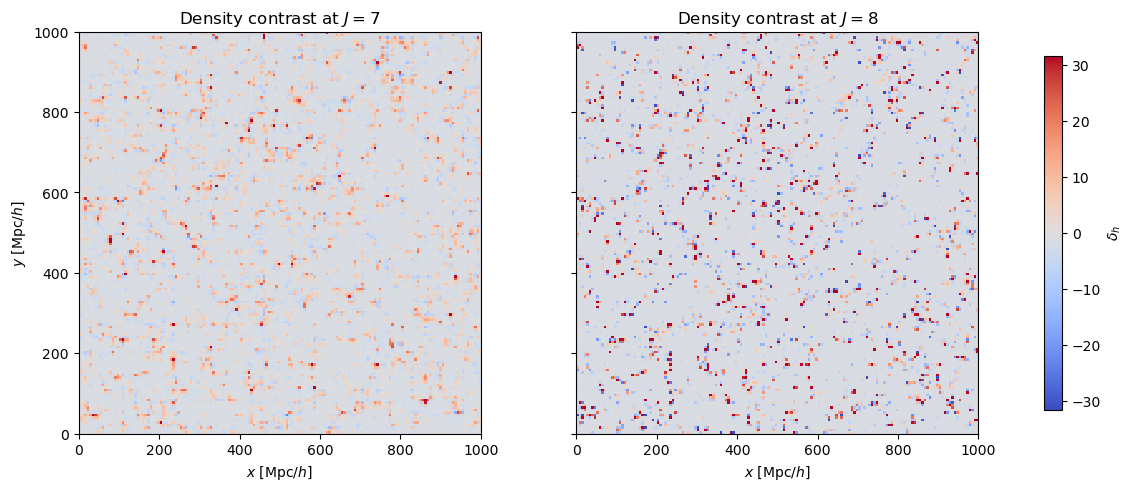

In [8]:
vmax = np.percentile(np.abs(np.concatenate([delta_j7.ravel(), delta_j8.ravel()])), 99.0)
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8), sharex=True, sharey=True, constrained_layout=True)
for ax, delta, J in zip(axes, [delta_j7, delta_j8], [7, 8]):
    image = ax.imshow(
        delta, origin="lower", extent=(0, box_size, 0, box_size),
        cmap="coolwarm", vmin=-vmax, vmax=vmax, interpolation="nearest",
    )
    ax.set_title(rf"Density contrast at $J={J}$")
    ax.set_xlabel(r"$x$ [Mpc/$h$]")
axes[0].set_ylabel(r"$y$ [Mpc/$h$]")
fig.colorbar(image, ax=axes, label=r"$\delta_h$", shrink=0.88)
fig.savefig("./figs/sfc_projection_resolution_j7_j8.png", dpi=180, bbox_inches="tight")
plt.show()


## 4. Change coordinates, then project once

Redshift-space distortions enter through particle coordinates. With the distant-observer line of sight along `z`, PyHermes shifts positions periodically and projects the transformed catalogue with the same SFC basis.


In [9]:
velocity = np.column_stack([halo_data["vel_x"], halo_data["vel_y"], halo_data["vel_z"]])
redshift = 0.0
hubble = hubble_at_redshift(redshift)
rsd_pos = redshift_space_positions(pos, velocity, box_size, hubble, redshift, los="z")
rsd_field = project_arrays(rsd_pos)
delta_rsd = density_contrast(rsd_field)


23:39:15 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <base> ...
23:39:15 - WARNING - pyhermes.param.parambase:ParamBase - Type mismatch for key: 'SFCProjection.particle_pos' !!!
23:39:15 - INFO - pyhermes.param.parambase:ParamBase - Default 'SFCProjection.threads' from '1' to '2'
23:39:15 - INFO - pyhermes.pipeline.pipeline:SFCProjection - SFCProjection runtime configuration: running on 1 MPI ranks with 2 threads per rank
23:39:15 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Preparing SFCProjection input fields ...
23:39:15 - INFO - pyhermes.pipeline.pipeline:SFCProjection - J=8, L=256, box_size=1000.0, phi_resolution=1024, wavelet_mode=db2, wavelet_level=10
23:39:15 - INFO - pyhermes.pipeline.pipeline:SFCProjection - No catalog_weight provided; using unit catalogue weights for 406728 particles.
23:39:15 - INFO - pyhermes.pipeline.pipeline:SFCProjection - Input particles ready | source=custom particle_pos array | particle_count=406728 | catalog

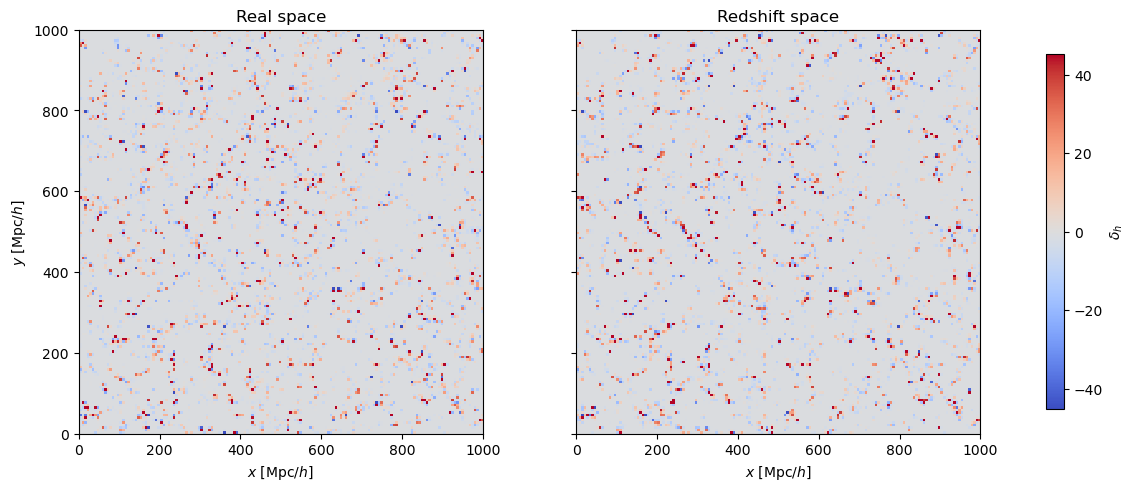

In [10]:
vmax = np.percentile(np.abs(np.concatenate([delta_j8.ravel(), delta_rsd.ravel()])), 99.0)
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.8), sharex=True, sharey=True, constrained_layout=True)
for ax, delta, title in zip(axes, [delta_j8, delta_rsd], ["Real space", "Redshift space"]):
    image = ax.imshow(
        delta, origin="lower", extent=(0, box_size, 0, box_size),
        cmap="coolwarm", vmin=-vmax, vmax=vmax, interpolation="nearest",
    )
    ax.set_title(title)
    ax.set_xlabel(r"$x$ [Mpc/$h$]")
axes[0].set_ylabel(r"$y$ [Mpc/$h$]")
fig.colorbar(image, ax=axes, label=r"$\delta_h$", shrink=0.88)
fig.savefig("./figs/sfc_projection_real_rsd_slice.png", dpi=180, bbox_inches="tight")
plt.show()


## 5. The companion particle dataset

When `save_particle_data: true`, `SFCProjection` writes the exact positions and scalar factors used by that projection. This compact companion lets particle-centred statistics recover their catalogue consistently. It is intentionally different from the richer public source NPZ, which also stores velocities, mass, and particle count.


In [11]:
particle_data = field_j8.get_particle_data()
print(f"companion arrays: {sorted(particle_data)}")
print(f"positions: {particle_data['pos'].shape}")
print(f"projection-weight sum: {particle_data['projection_weight'].sum():.6g}")


companion arrays: ['catalog_weight', 'field_value', 'normalized_catalog_weight', 'pos', 'projection_weight']
positions: (406728, 3)
projection-weight sum: 1


## Next steps

The projected field is now ready for `window.ipynb`, `counting.ipynb`, and the correlation notebooks. For the larger precomputed example suite (higher `J`, mass weighting, redshift space, and random catalogues), run:

In [14]:
# This script is an advanced convenience tool, not a prerequisite for the tutorial path.
! python scripts/prepare_sfc_fields.py

Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples

== Preparing the example halo catalog ==
Archive already exists: data/quijote_halos.tar.gz
Catalog already exists: data/quijote_halos
23:41:38 - INFO - pyhermes.io.readers:read_particle_data - Selected input particle format: fof
23:41:38 - INFO - pyhermes.io.readers:read_fof - Reading Quijote FoF halo data from ---> data/quijote_halos/8000 <---

== Packing the Quick Start NPZ catalogue ==
NPZ catalogue already exists: data/quijote_halos_8000_snap004.npz
SHA256: b2b4b8c2fb91fa857e21b43d943cc32a2c423ee7cf5d7f13dede608264b08ef6

== Building real-space SFCField ==
Output already exists: output/quijote8000_snap004_sfc.pkl

== Building J=9 SFCField ==
Output already exists: output/quijote8000_snap004_sfc_J9.pkl

== Building mass-weighted SFCField ==
Output already exists: output/quijote8000_snap004_sfc_massweight.pkl

== Preparing redshift-space particle positions ==

== Building redshift-space SFCField with z-axis 